# 3. MusSkl diffloop

Part of the **[Fig. 6 chapter](fig6.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{REF_ROOT}/blacklist/hg38_bismark_loop_blacklist.bed'`  ·  _loop calls_
- `f'{indir}{ct}.{matrix}.cool'`  ·  _contacts (cool)_
- `f'{indir}{ct}.{matrix}2.cool'`  ·  _contacts (cool)_
- `f'{indir}{ct}.loop.bedpe'`  ·  _loop calls_
- `f'{outdir}mc3c_3group_{matrix}pv.cool'`  ·  _contacts (cool)_
- `f'{outdir}merged_loop.hdf'`  ·  _loop calls_
- `f'{indir}{ct}.{m}.cool'`  ·  _contacts (cool)_
- `f'{outdir}loop_Q.hdf'`  ·  _loop calls_
- `f'{outdir}loop_T.hdf'`  ·  _loop calls_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

[repro_guard] active — READ-ONLY (all writes skipped; inline figures still render)


In [2]:
import os
import cooler
import pathlib
import numpy as np
import pandas as pd
from scipy.sparse import load_npz, save_npz, vstack, csr_matrix, triu
from scipy.stats import f, zscore, ranksums
from schicluster.cool.utilities import get_chrom_offsets
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor, as_completed
from glob import glob

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import cm as cm

import seaborn as sns

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [3]:
# flist = glob('/entex/loop/250715-SklMus-mc3c/*/*/*')
# filedict = {i.split('/')[-1]:i for i in flist}
# leg = filedict.keys()
indir = f'{ENTEX_ROOT}/analysis/Mus-Skl/cool_new/'
ctgroup = [[f'mc{i}-3c{i}'] for i in range(3)]
outdir = f'{ENTEX_ROOT}/analysis/Mus-Skl/diffloop_3group_new/'
res = 10000

In [4]:
if not os.path.exists(outdir):
    os.mkdir(outdir)

In [5]:
import cooler
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]
bins_df = cooler.binnify(chrom_sizes, res)
chrom_offset = get_chrom_offsets(bins_df)


In [6]:
bkl = pd.read_csv(f'{REF_ROOT}/blacklist/hg38_bismark_loop_blacklist.bed',
                  sep='\t', header=None, index_col=None)

In [7]:
def compute_anova(c, matrix):
    # c, matrix = args
    ngene = int(chrom_sizes.loc[c] // res) + 1
    bkl_tmp = bkl.loc[(bkl[0]==c), [1,2]].values // res
    cov = np.zeros(ngene)
    for xx,yy in bkl_tmp:
        cov[xx-7:yy+7] = 1
    tot, last = 0, 0
    Esum, E2sum, Elast, E2last, ss_intra = [csr_matrix((ngene, ngene)) for i in range(5)]
    for ctlist in ctgroup:
        for ct in ctlist:
            cool_e = cooler.Cooler(f'{indir}{ct}.{matrix}.cool')
            E = triu(cool_e.matrix(balance=False, sparse=True).fetch(c))
            cool_e2 = cooler.Cooler(f'{indir}{ct}.{matrix}2.cool')
            E2 = triu(cool_e2.matrix(balance=False, sparse=True).fetch(c))
            n = cool_e.info['group_n_cells']
            Esum += E * n
            E2sum += E2 * n
            tot += n
            # print(c, ct)
        Egroup = Esum - Elast
        E2group = E2sum - E2last
        Egroup.data = Egroup.data ** 2 / (tot - last)
        ss_intra += (E2group - Egroup)
        Elast = Esum.copy()
        E2last = E2sum.copy()
        last = tot
    Esum.data = Esum.data ** 2 / tot
    ss_total = E2sum - Esum
    ss_intra.data = 1 / ss_intra.data
    ss_total = ss_total.multiply(ss_intra)
    # print(c, ss_total.data.min(), ss_intra.data.min())

    ss_total.data = (ss_total.data - 1) * (tot - len(ctgroup)) / (len(ctgroup) - 1)
    ss_total = ss_total.tocoo()
    bklfilter = np.logical_and(cov[ss_total.row]==0, cov[ss_total.col]==0)
    distfilter = np.logical_and((ss_total.col-ss_total.row)>5, (ss_total.col-ss_total.row)<500)
    idxfilter = np.logical_and(bklfilter, distfilter)
    # print(idxfilter.sum(), len(idxfilter))
    ss_total = csr_matrix((ss_total.data[idxfilter], (ss_total.row[idxfilter], ss_total.col[idxfilter])), (ngene, ngene))
    save_npz(f'{outdir}mc3c_3group_{matrix}pv_{c}.npz', ss_total)

    return [c, matrix, tot]



In [8]:
cpu = 15
with ProcessPoolExecutor(cpu) as executor:
    futures = []
    for x in chrom_sizes.index:
        for y in ['Q', 'E', 'T']:
            future = executor.submit(
                compute_anova,
                c=x,
                matrix=y,
            )
            futures.append(future)

    # result = []
    for future in as_completed(futures):
        # result.append(future.result())
        # c1, c2 = result[-1][0], result[-1][1]
        tmp = future.result()
        print(f'{tmp[0]} {tmp[1]} finished')
        

chr4 E finished


chr4 Q finished


chr3 Q finished


chr3 T finished


chr5 T finished


...

chr19 Q finished
chr20 T finished
chr16 E finished


chr18 T finished
chr18 Q finished
chr14 T finished
chr22 Q finished


chr21 E finished
chr20 E finished


chr21 T finished
chr22 T finished


chr22 E finished


In [9]:
def chrom_iterator(input_dir, chrom_order, chrom_offset):
    for chrom in chrom_order:
        output_path = f'{input_dir}_{chrom}.npz'
        if not pathlib.Path(output_path).exists():
            continue
        chunk_size = 5000000
        data = load_npz(output_path).tocoo()
        df = pd.DataFrame({'bin1_id': data.row, 'bin2_id': data.col, 'count': data.data})
        df = df[df['bin1_id'] <= df['bin2_id']]
        for i, chunk_start in enumerate(range(0, df.shape[0], chunk_size)):
            chunk = df.iloc[chunk_start:chunk_start + chunk_size]
            chunk.iloc[:, :2] += chrom_offset[chrom]
            yield chunk


In [10]:
for matrix in ['Q', 'E', 'T']:
    output_path = f'{outdir}mc3c_3group_{matrix}pv'
    cooler.create_cooler(cool_uri=f'{output_path}.cool',
                         bins=bins_df,
                         pixels=chrom_iterator(input_dir=output_path,
                                               chrom_order=chrom_sizes.index,
                                               chrom_offset=chrom_offset
                                              ),
                         ordered=True,
                         dtypes={'count': np.float32})


In [11]:
os.system(f'rm {outdir}mc3c_3group_*pv_c*.npz')

0

In [12]:
leg = pd.Index([f'mc{i}-3c{i}' for i in range(3)])

In [13]:
loopall = [pd.read_csv(f'{indir}{ct}.loop.bedpe', sep='\t', index_col=None, header=None) for ct in leg]
loopall = pd.concat(loopall, axis=0)
loopall = loopall.drop([6], axis=1).drop_duplicates(subset=[0,1,4]).sort_values([0,1,4])
loopall = pd.concat([loopall[(loopall[0]==c).values] for c in chrom_sizes.index])
loopall.index = np.arange(loopall.shape[0])
loopall


,0,1,2,3,4,5
0,chr1,1790000,1800000,chr1,1880000,1890000
1,chr1,7950000,7960000,chr1,8290000,8300000
2,chr1,7950000,7960000,chr1,8300000,8310000
3,chr1,7950000,7960000,chr1,8310000,8320000
4,chr1,7950000,7960000,chr1,8320000,8330000
...,...,...,...,...,...,...
97320,chr22,46150000,46160000,chr22,46240000,46250000
97321,chr22,46150000,46160000,chr22,46250000,46260000
97322,chr22,46150000,46160000,chr22,46260000,46270000
97323,chr22,46150000,46160000,chr22,46270000,46280000


In [14]:
loopall.to_csv(f'{outdir}merged_loop.bedpe', sep='\t', index=False, header=False)
loopall.to_hdf(f'{outdir}merged_loop.hdf', key='data')


In [15]:
for c in chrom_sizes.index:
    loopfilter = (loopall[0]==c)
    looptmp = loopall.loc[loopfilter, [1,4]].values // res
    for matrix in ['Q', 'E', 'T']:
        cool = cooler.Cooler(f'{outdir}mc3c_3group_{matrix}pv.cool')
        pv = triu(cool.matrix(balance=False, sparse=True).fetch(c)).tocsr()
        loopall.loc[loopfilter, f'{matrix}anova'] = pv[(looptmp[:,0], looptmp[:,1])].A1
    print(c)


chr1


chr2


chr3


chr4


chr5


...

chr18


chr19


chr20


chr21


chr22


In [16]:
loopall.to_hdf(f'{outdir}merged_loop.hdf', key='data')


## Load Loop Q

In [17]:
loopall = pd.read_hdf(f'{outdir}merged_loop.hdf', key='data')
loopall

,0,1,2,3,4,5,Qanova,Eanova,Tanova,Tfdr,Efdr,Qfdr
0,chr1,1790000,1800000,chr1,1880000,1890000,3.958630,7.175738,2.449823,4.219277e-02,2.481897e-07,0.001614
1,chr1,7950000,7960000,chr1,8290000,8300000,1.944837,1.587136,2.187596,7.151076e-02,1.769729e-01,0.117848
2,chr1,7950000,7960000,chr1,8300000,8310000,1.971611,2.699039,5.436210,4.790106e-05,1.749322e-02,0.112043
3,chr1,7950000,7960000,chr1,8310000,8320000,2.343121,3.026160,8.228224,5.034994e-08,8.328814e-03,0.054312
4,chr1,7950000,7960000,chr1,8320000,8330000,3.194250,1.796813,6.157161,8.403471e-06,1.182902e-01,0.009041
...,...,...,...,...,...,...,...,...,...,...,...,...
97320,chr22,46150000,46160000,chr22,46240000,46250000,6.710564,7.090497,4.496578,4.452082e-04,3.105861e-07,0.000002
97321,chr22,46150000,46160000,chr22,46250000,46260000,5.441721,7.532025,5.377615,5.515809e-05,9.676083e-08,0.000048
97322,chr22,46150000,46160000,chr22,46260000,46270000,5.548141,8.151396,6.509145,3.558778e-06,1.868346e-08,0.000037
97323,chr22,46150000,46160000,chr22,46270000,46280000,3.463969,3.579064,2.270262,6.065171e-02,2.275584e-03,0.004970


In [18]:
leg = glob(f'{indir}*loop.bedpe')
leg = pd.Index([xx.split('/')[-1].split('.')[0] for xx in np.sort(leg)])
leg

Index(['mc0-3c0', 'mc0-3c1', 'mc0-3c2', 'mc1-3c1', 'mc1-3c2', 'mc2-3c1',
       'mc2-3c2'],
      dtype='object')

In [19]:
def load_Q(ct, m):
    tmp = []
    cool_file = cooler.Cooler(f'{indir}{ct}.{m}.cool').matrix(balance=False, sparse=True)
    for c in chrom_sizes.index:
        mat = cool_file.fetch(c).tocsr()
        tmp.append(mat[(loopall.loc[loopall[0]==c, 1].values // res, loopall.loc[loopall[0]==c, 4].values // res)].A1)
        # print(ct, c)
    return [ct, np.concatenate(tmp)]


In [20]:
cpu = 7
with ProcessPoolExecutor(cpu) as executor:
    futures = []
    for xx in leg:
        future = executor.submit(
            load_Q,
            ct=xx,
            m='Q'
        )
        futures.append(future)

    loopq = []
    for future in as_completed(futures):
        tmp = future.result()
        loopq.append(pd.DataFrame(tmp[1], columns=[tmp[0]]))
        print(f'{tmp[0]} finished')
        

mc2-3c2 finished
mc0-3c0 finished
mc2-3c1 finished


mc1-3c1 finished


mc1-3c2 finished
mc0-3c2 finished


mc0-3c1 finished


In [21]:
loopq = pd.concat(loopq, axis=1)
loopq = loopq[leg]


In [22]:
loopq.to_hdf(f'{outdir}loop_Q.hdf', key='data')


In [23]:
cpu = 5
with ProcessPoolExecutor(cpu) as executor:
    futures = []
    for xx in leg:
        future = executor.submit(
            load_Q,
            ct=xx,
            m='T'
        )
        futures.append(future)

    loopt = []
    for future in as_completed(futures):
        tmp = future.result()
        loopt.append(pd.DataFrame(tmp[1], columns=[tmp[0]]))
        print(f'{tmp[0]} finished')
        

mc1-3c1 finished
mc1-3c2 finished


mc0-3c2 finished


mc0-3c0 finished


mc0-3c1 finished


mc2-3c1 finished


mc2-3c2 finished


In [24]:
loopt = pd.concat(loopt, axis=1)
loopt = loopt[leg]


In [25]:
loopt.to_hdf(f'{outdir}loop_T.hdf', key='data')


In [26]:
loopq = pd.read_hdf(f'{outdir}loop_Q.hdf', key='data')
loopt = pd.read_hdf(f'{outdir}loop_T.hdf', key='data')


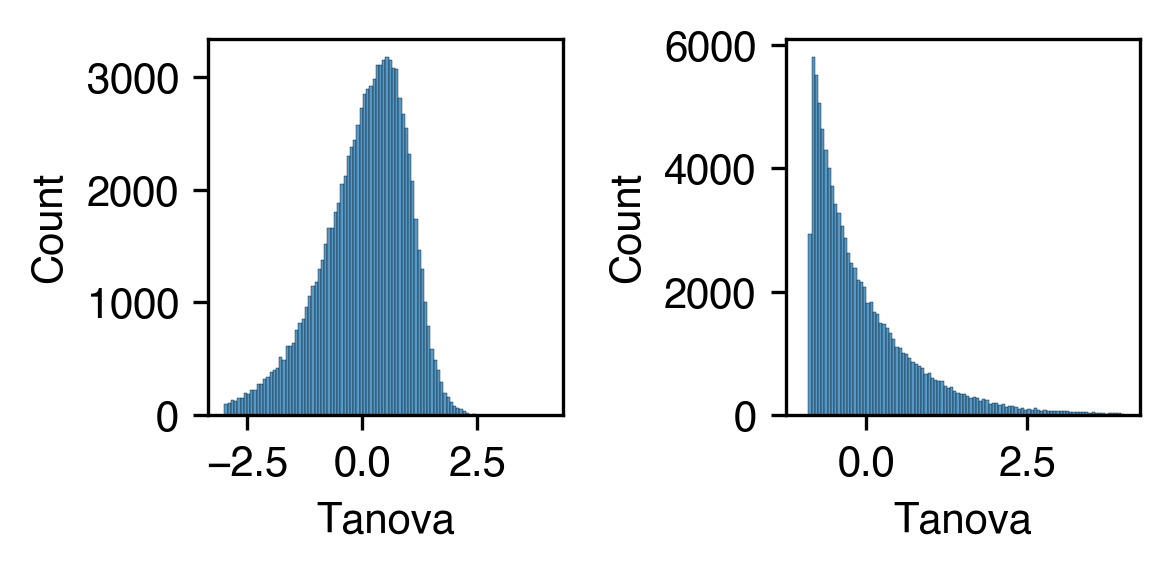

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=300)
ax = axes[0]
sns.histplot(zscore(np.log10(loopall['Tanova'])), bins=100, binrange=(-3,4), ax=ax)
ax = axes[1]
sns.histplot(zscore(loopall['Tanova']), bins=100, binrange=(-1,4), ax=ax)
plt.tight_layout()


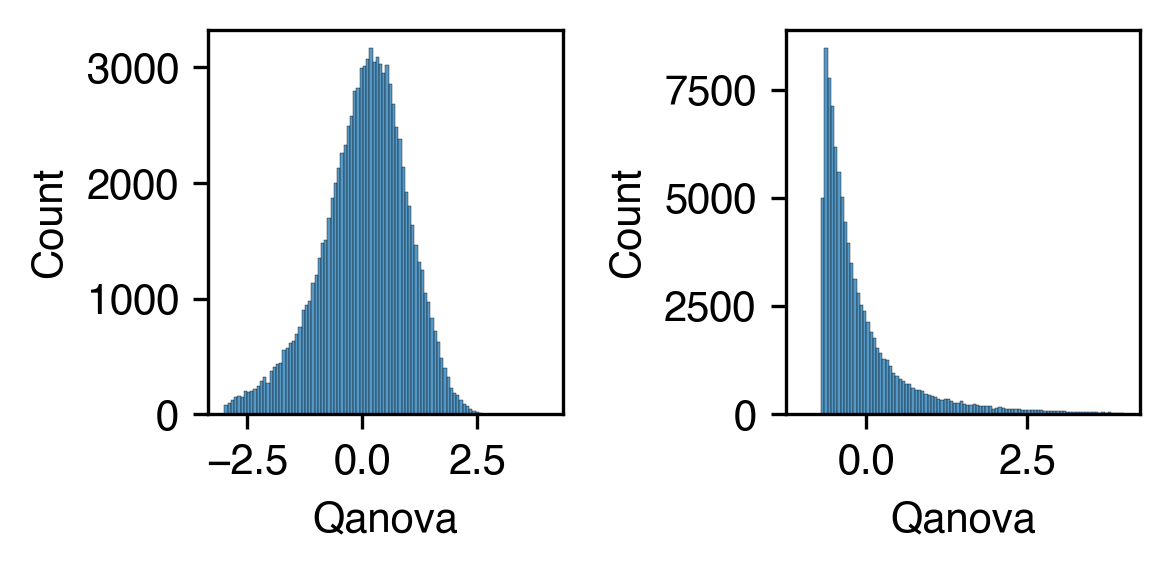

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=300)
ax = axes[0]
sns.histplot(zscore(np.log10(loopall['Qanova'])), bins=100, binrange=(-3,4), ax=ax)
ax = axes[1]
sns.histplot(zscore(loopall['Qanova']), bins=100, binrange=(-1,4), ax=ax)
plt.tight_layout()


In [29]:
from scipy.stats import pearsonr, zscore, norm


In [30]:
thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)


1.9599639845400545 1.0364333894937898


In [31]:
selb = ((zscore(loopall['Qanova'])>thres2) & (zscore(loopall['Tanova'])>thres2))


In [32]:
tmpq = loopq.loc[selb].values
tmpq = zscore(tmpq, axis=1)


In [33]:
tmpt = loopt.loc[selb].values
tmpt = zscore(tmpt, axis=1)


In [34]:
np.random.seed(0)
sel = np.random.choice(np.arange(len(tmpq)), 2000, False)


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


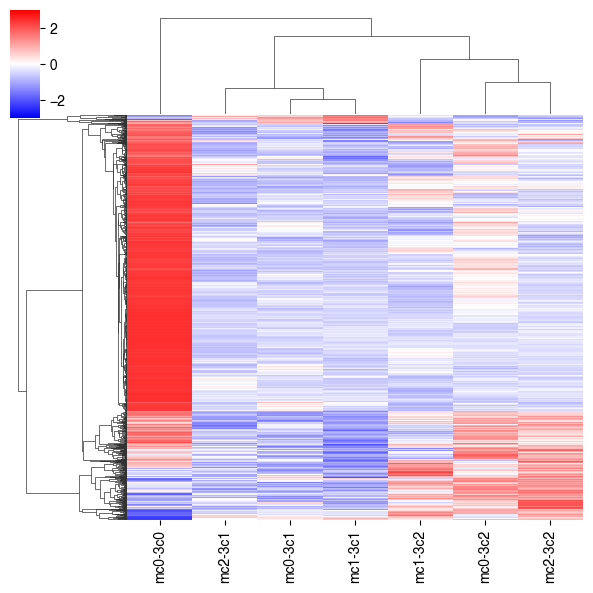

In [35]:
cg = sns.clustermap(tmpq[sel], cmap='bwr', vmin=-3, vmax=3, metric='cosine', xticklabels=leg, yticklabels=[], figsize=(6,6))


In [36]:
rorder = cg.dendrogram_row.reordered_ind.copy()
corder = cg.dendrogram_col.reordered_ind.copy()

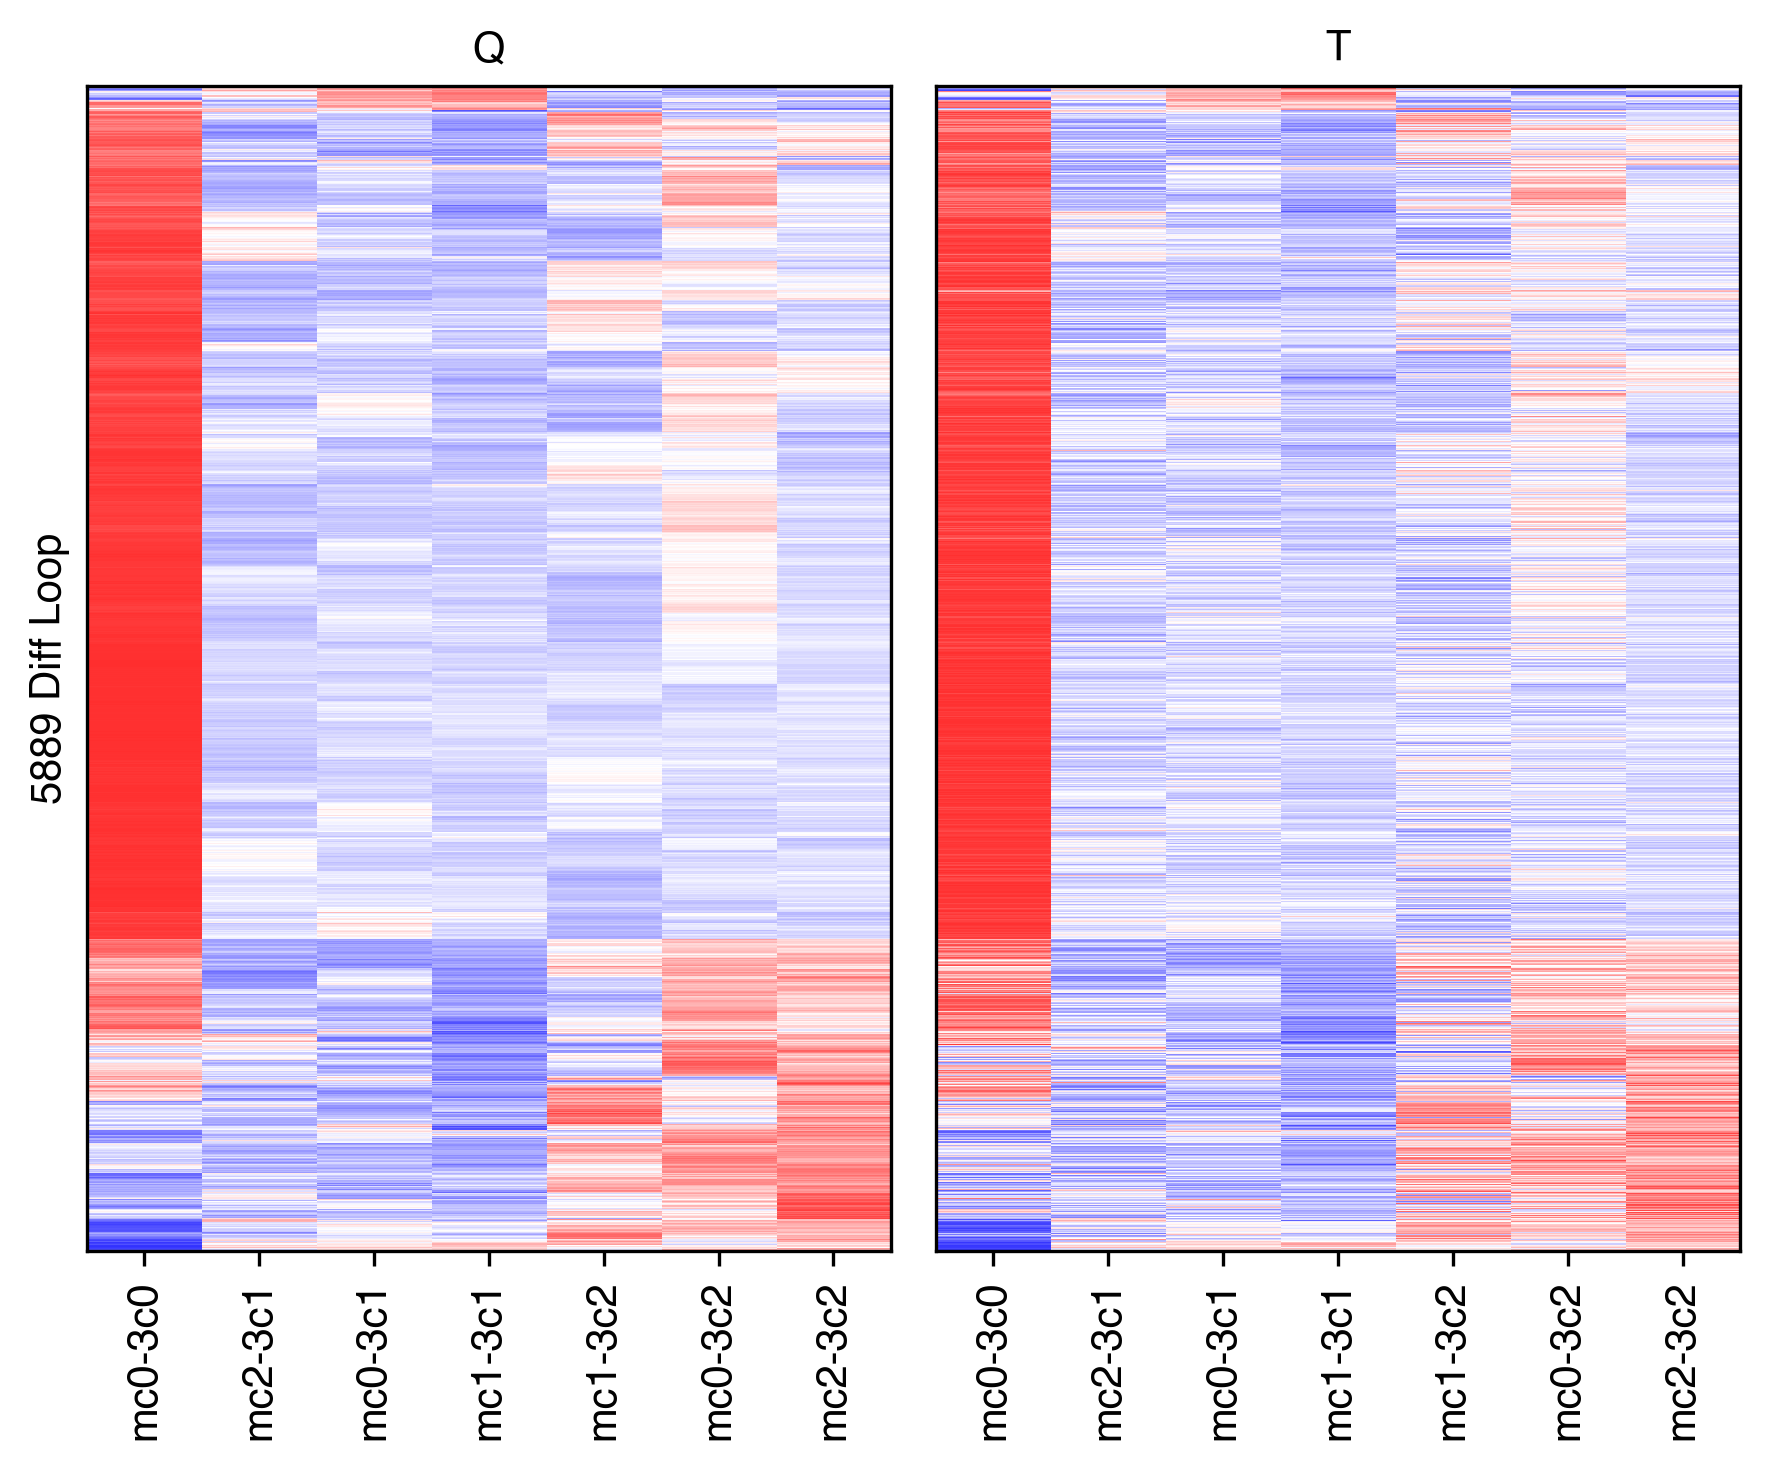

In [37]:
fig, axes = plt.subplots(1, 2, sharey='all', figsize=(6, 5), dpi=300)

ax = axes[0]
ax.imshow(tmpq[np.ix_(sel[rorder], corder)], cmap='bwr', aspect='auto', vmin=-3, vmax=3, interpolation='none')
ax.set_title('Q', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(len(leg)))
ax.set_xticklabels(leg[corder], rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{tmpq.shape[0]} Diff Loop')

ax = axes[1]
ax.imshow(tmpt[np.ix_(sel[rorder], corder)], cmap='bwr', aspect='auto', vmin=-3, vmax=3, interpolation='none')
ax.set_title('T', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(len(leg)))
ax.set_xticklabels(leg[corder], rotation=90)

plt.tight_layout()
